In [39]:
# ==========================================
# Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Evaluation Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
# ==========================================
# Load ML-Ready Healthcare Dataset
# ==========================================

df = pd.read_csv("../data/processed/ckd_ml_ready.csv")

# Display first five rows
df.head()

,id,age,bp,sg,al,su,pc,pcc,ba,bgr,...,wbcc,rbcc,htn,dm,cad,appet,pe,ane,Unnamed: 26,class
0,-1.727726,-0.210031,0.254214,0.421486,0.076249,-0.380269,0.484322,-0.342518,-0.241249,-0.320122,...,-0.197314,0.550044,1.311903,1.385535,-0.304789,-0.510723,-0.472690,-0.420084,0.050063,0
1,-1.719066,-2.627234,-1.972476,0.421486,2.363728,-0.380269,0.484322,-0.342518,-0.241249,-0.320122,...,-0.909782,0.074073,-0.762252,-0.721743,-0.304789,-0.510723,-0.472690,-0.420084,0.050063,0
2,-1.710406,0.615355,0.254214,-1.421074,0.838742,2.507853,0.484322,-0.342518,-0.241249,3.697618,...,-0.316059,0.074073,-0.762252,1.385535,-0.304789,1.965511,-0.472690,2.380476,0.050063,0
3,-1.701745,-0.210031,-0.488016,-2.342354,2.363728,-0.380269,-2.064742,2.919556,-0.241249,-0.373337,...,-0.632711,-0.996862,1.311903,-0.721743,-0.304789,1.965511,2.048324,2.380476,0.050063,0
4,-1.693085,-0.033163,0.254214,-1.421074,0.838742,-0.380269,0.484322,-0.342518,-0.241249,-0.519679,...,-0.395222,-0.163913,-0.762252,-0.721743,-0.304789,-0.510723,-0.472690,-0.420084,0.050063,0


In [41]:
# ==========================================
# Dataset Shape
# ==========================================

print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(500, 26)


In [42]:
# ==========================================
# Dataset Information
# ==========================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           500 non-null    float64
 1   age          500 non-null    float64
 2   bp           500 non-null    float64
 3   sg           500 non-null    float64
 4   al           500 non-null    float64
 5   su           500 non-null    float64
 6   pc           500 non-null    float64
 7   pcc          500 non-null    float64
 8   ba           500 non-null    float64
 9   bgr          500 non-null    float64
 10  bu           500 non-null    float64
 11  sc           500 non-null    float64
 12  sod          500 non-null    float64
 13  pot          500 non-null    float64
 14  hemo         500 non-null    float64
 15  pcv          500 non-null    float64
 16  wbcc         500 non-null    float64
 17  rbcc         500 non-null    float64
 18  htn          500 non-null    float64
 19  dm           500 no

In [43]:
# ==========================================
# Check Class Distribution
# ==========================================

print(df['class'].value_counts())

class
0    250
1    250
Name: count, dtype: int64


In [44]:
# ==========================================
# Separate Features and Target Variable
# ==========================================

X = df.drop("class", axis=1)

y = df["class"]

In [45]:
# ==========================================
# Train-Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    
    X,
    y,
    
    test_size=0.2,
    
    random_state=42,
    
    stratify=y
)

In [46]:
# ==========================================
# Display Training and Testing Shapes
# ==========================================

print("Training Feature Shape:", X_train.shape)

print("Testing Feature Shape:", X_test.shape)

print("Training Target Shape:", y_train.shape)

print("Testing Target Shape:", y_test.shape)

Training Feature Shape: (400, 25)
Testing Feature Shape: (100, 25)
Training Target Shape: (400,)
Testing Target Shape: (100,)


In [47]:
# ==========================================
# Initialize Logistic Regression Model
# ==========================================

log_model = LogisticRegression(max_iter=1000)

In [48]:
# ==========================================
# Train Logistic Regression Model
# ==========================================

log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [49]:
# ==========================================
# Generate Predictions
# ==========================================

y_pred = log_model.predict(X_test)

In [50]:
# ==========================================
# Display Predictions
# ==========================================

print("Predicted Values:")

print(y_pred[:10])

Predicted Values:
[1 0 0 1 1 1 1 0 0 0]


In [51]:
# ==========================================
# Calculate Model Accuracy
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:")

print(round(accuracy * 100, 2), "%")

Logistic Regression Accuracy:
100.0 %


In [52]:
# ==========================================
# Classification Report
# ==========================================

print("Classification Report:\n")

print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [53]:
# ==========================================
# Generate Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[50  0]
 [ 0 50]]


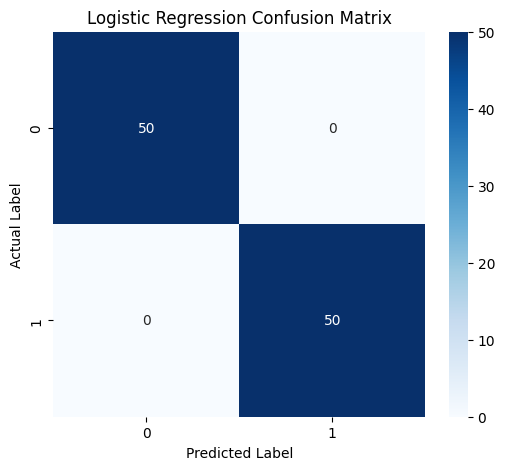

In [54]:
# ==========================================
# Visualize Confusion Matrix
# ==========================================

plt.figure(figsize=(6,5))

sns.heatmap(
    
    cm,
    
    annot=True,
    
    fmt='d',
    
    cmap='Blues'
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.show()

In [55]:
# ==========================================
# Store Baseline Model Results
# ==========================================

baseline_results = pd.DataFrame({

    "Model": ["Logistic Regression"],

    "Accuracy": [accuracy]
})

baseline_results

,Model,Accuracy
0,Logistic Regression,1.0


In [56]:
# ==========================================
# Export Baseline Results
# ==========================================

baseline_results.to_csv(

    "../reports/logistic_regression_baseline_results.csv",
    
    index=False
)

In [57]:
# ==========================================
# Final Workflow Confirmation
# ==========================================

print("Baseline Logistic Regression Workflow Completed Successfully")

Baseline Logistic Regression Workflow Completed Successfully


In [58]:
# ==========================================
# Initialize Decision Tree Classifier
# ==========================================

from sklearn.tree import DecisionTreeClassifier


dt_model = DecisionTreeClassifier(
    
    criterion='gini',
    
    max_depth=5,
    
    random_state=42
)

In [59]:
# ==========================================
# Train Decision Tree Model
# ==========================================

dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [60]:
# ==========================================
# Generate Predictions
# ==========================================

y_pred_dt = dt_model.predict(X_test)

In [61]:
# ==========================================
# Decision Tree Accuracy
# ==========================================

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:")

print(round(dt_accuracy * 100, 2), "%")

Decision Tree Accuracy:
100.0 %


In [62]:
# ==========================================
# Classification Report
# ==========================================

print("Decision Tree Classification Report:\n")

print(classification_report(y_test, y_pred_dt))

Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [63]:
# ==========================================
# Generate Confusion Matrix
# ==========================================

dt_cm = confusion_matrix(y_test, y_pred_dt)

print(dt_cm)

[[50  0]
 [ 0 50]]


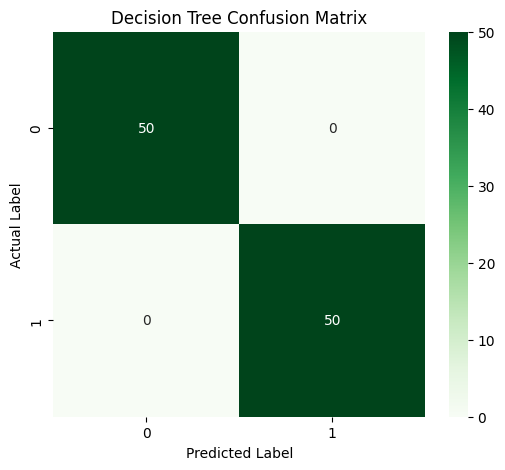

In [64]:
# ==========================================
# Visualize Confusion Matrix
# ==========================================

plt.figure(figsize=(6,5))

sns.heatmap(
    
    dt_cm,
    
    annot=True,
    
    fmt='d',
    
    cmap='Greens'
)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.show()

In [65]:
# ==========================================
# Remove Unnecessary Identifier Column
# ==========================================

df = df.drop("id", axis=1)

In [66]:
# ==========================================
# Separate Features and Target Variable
# ==========================================

X = df.drop("class", axis=1)

y = df["class"]

In [67]:
# ==========================================
# Initialize Decision Tree Classifier
# ==========================================

dt_model = DecisionTreeClassifier(

    criterion='entropy',

   

    min_samples_split=20,

    min_samples_leaf=10,

    random_state=42
)

In [68]:
# Train Decision Tree Model

dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cu

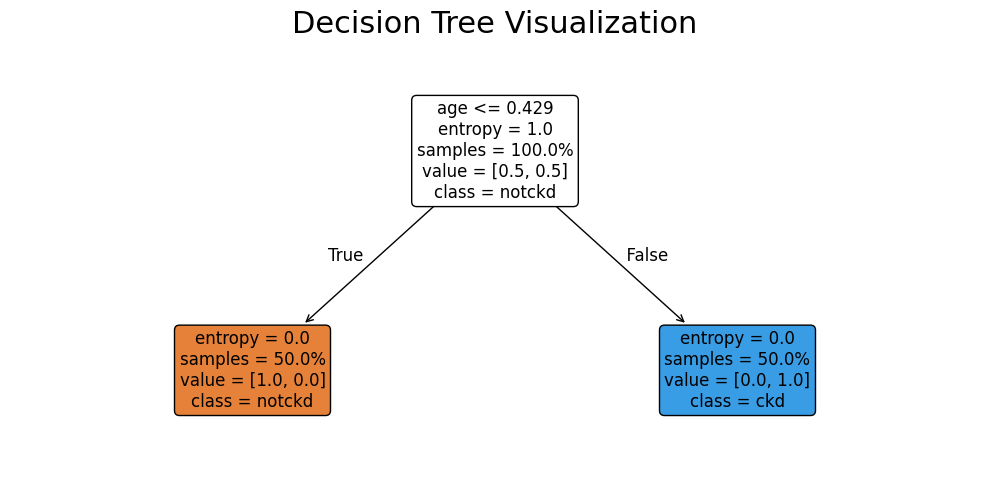

In [71]:
# ==========================================
# Visualize Decision Tree Structure
# ==========================================
from sklearn.tree import plot_tree

plt.figure(figsize=(10,5))

plot_tree(

    dt_model,

    filled=True,

    rounded=True,

    fontsize=12,

    proportion=True,

    feature_names=X.columns,

    class_names=['notckd', 'ckd']
)

plt.title(
    "Decision Tree Visualization",
    fontsize=22
)

plt.tight_layout()

plt.show()

In [72]:
# ==========================================
# Training Accuracy
# ==========================================

train_accuracy = dt_model.score(X_train, y_train)

print("Training Accuracy:")

print(round(train_accuracy * 100, 2), "%")

Training Accuracy:
100.0 %


In [73]:
# ==========================================
# Testing Accuracy
# ==========================================

test_accuracy = dt_model.score(X_test, y_test)

print("Testing Accuracy:")

print(round(test_accuracy * 100, 2), "%")

Testing Accuracy:
100.0 %


In [74]:
# ==========================================
# Overfitting Analysis
# ==========================================

print("Accuracy Difference:")

print(round(train_accuracy - test_accuracy, 4))

Accuracy Difference:
0.0


In [75]:
# ==========================================
# Compare with Logistic Regression
# ==========================================

comparison_df = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],

    "Accuracy": [
        0.99,   
        dt_accuracy
    ]
})

comparison_df

,Model,Accuracy
0,Logistic Regression,0.99
1,Decision Tree,1.00


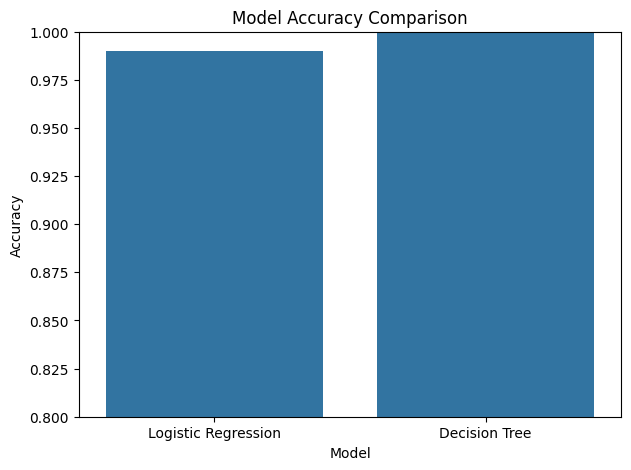

In [76]:
# ==========================================
# Visualize Model Comparison
# ==========================================

plt.figure(figsize=(7,5))

sns.barplot(
    
    x='Model',
    
    y='Accuracy',
    
    data=comparison_df
)

plt.title("Model Accuracy Comparison")

plt.ylim(0.8, 1.0)

plt.show()